In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


in this notebook we going to make the data model ready and apply all the changes we have done so far to check how well the model perform on the data 


# feature eng:
            1. feature transform
            2. feature construct 
            3. feature selection 
            4. feature extraction
            

In [122]:
df=pd.read_csv("D:\\skill improvement\\churn data\\data\\Churn_Modelling.csv")

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


# observation:
there is no missing values and no data type to be changes 

In [124]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6998,6999,15640074,Barrett,666,Spain,Female,47,5,0.00,1,0,0,166650.90,1
9123,9124,15679029,Kung,718,France,Male,33,7,102874.28,1,0,0,117841.06,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
7895,7896,15660571,Halpern,668,Spain,Male,43,10,113034.31,1,1,1,100423.88,0
9226,9227,15779913,Davidson,586,France,Male,27,5,130231.80,2,1,1,192427.16,0


## Dropping Non-Predictive Columns
RowNumber, CustomerId, and Surname carry no genuine predictive signal — 
RowNumber is just row order, CustomerId is unique per customer so it can't 
generalize, and Surname has no logical link to churn behavior. Dropped 
directly without model testing, unlike HasCrCard/CreditScore which will 
be tested in the modeling phase before any drop decision.

In [125]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [126]:
df.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
4896,605,France,Male,41,5,91612.91,1,1,1,28427.84,0
8097,626,France,Female,52,0,0.00,2,1,0,32159.46,1
7491,622,France,Male,40,4,99799.76,2,1,0,197372.13,0
2506,695,Spain,Male,44,8,0.00,2,1,1,70974.13,0
827,758,Spain,Male,56,1,0.00,2,1,1,10643.38,0


 # OULIER DETECTION :
 COLUMNS=CREDITSCORE,AGE,TENURE,BALANCE,NUMOFPRODUCTS,HASCRCARD,ISACTIVEMEMBER,ESTIMATEDSALARY

In [127]:
continue_values=[]
distinct_values=[]
for i in df.columns:
    if df[i].nunique()>11:
        continue_values.append(i)
    else:
        distinct_values.append(i)

In [128]:
# # creating graph for ecry continoues values/columns:
# for i in continue_values:
#     plt.figure(figsize=(10,5))
#     sns.boxplot(df[i])
#     plt.title(f'Distribution of {i}')
#     plt.show()

<Axes: ylabel='CreditScore'>

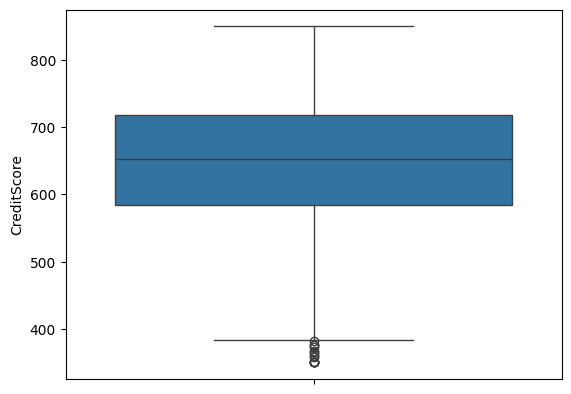

In [129]:
sns.boxplot(df['CreditScore'])

<Axes: xlabel='CreditScore', ylabel='Count'>

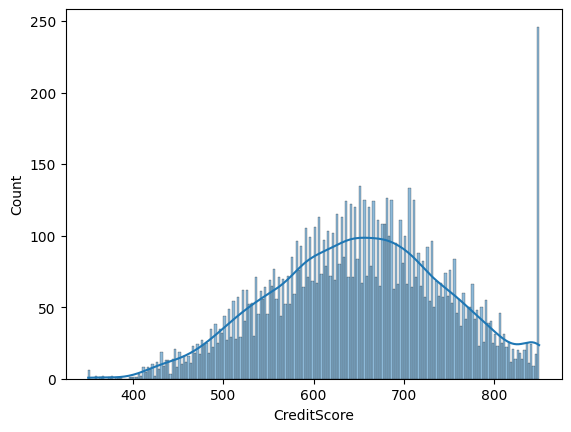

In [130]:
sns.histplot(df['CreditScore'],bins=200,kde=True)

In [131]:
df['CreditScore'].value_counts()

CreditScore
850    233
678     63
655     54
705     53
667     53
      ... 
358      1
412      1
382      1
373      1
419      1
Name: count, Length: 460, dtype: int64

In [132]:
print(f"no of customer with credit score low than 400 {df[df['CreditScore']<400].shape}")
df[df['CreditScore']<400]

no of customer with credit score low than 400 (19, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
942,376,France,Female,46,6,0.00,1,1,0,157333.69,1
1193,363,Spain,Female,28,6,146098.43,3,1,0,100615.14,1
1201,399,Germany,Male,46,2,127655.22,1,1,0,139994.68,1
1405,359,France,Female,44,6,128747.69,1,1,0,146955.71,1
1631,350,Spain,Male,54,1,152677.48,1,1,1,191973.49,1
1838,350,Germany,Male,39,0,109733.20,2,0,0,123602.11,1
1962,358,Spain,Female,52,8,143542.36,3,1,0,141959.11,1
2473,351,Germany,Female,57,4,163146.46,1,1,0,169621.69,1
2579,365,Germany,Male,30,0,127760.07,1,1,0,81537.85,1


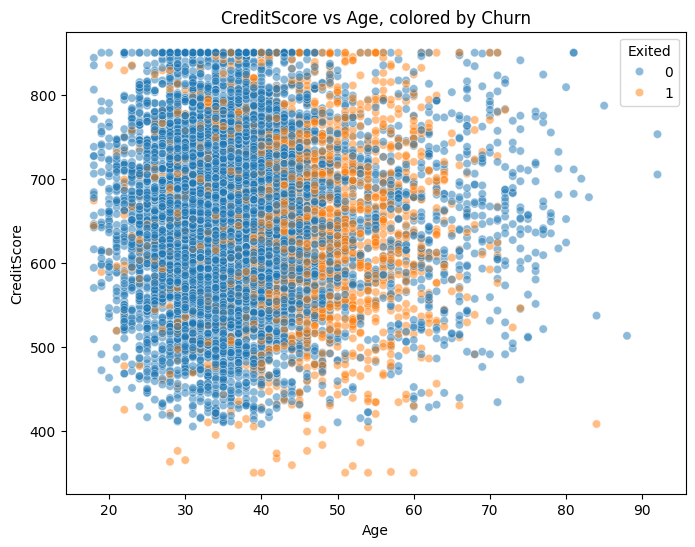

In [133]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Age', y='CreditScore', hue='Exited', alpha=0.5)
plt.title('CreditScore vs Age, colored by Churn')
plt.show()

# onservation
 CreditScore outliers (n=19, all below 400) checked against domain range (300-850) 
 and confirmed as valid, plausible scores - not data errors. Retained in dataset 
 since they represent real customers and show a distinct churn pattern worth 
preserving for the model to learn from.

In [134]:
continue_values

['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

<Axes: ylabel='Age'>

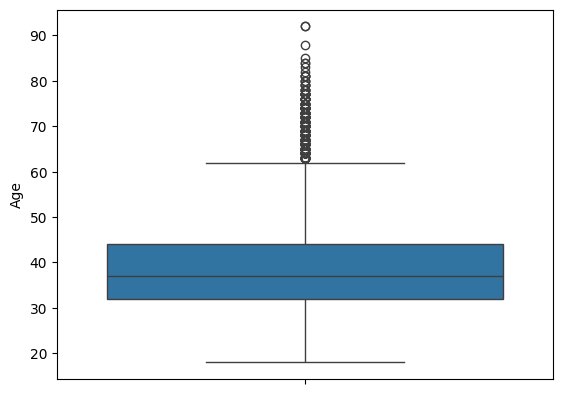

In [135]:
sns.boxplot(df['Age'])

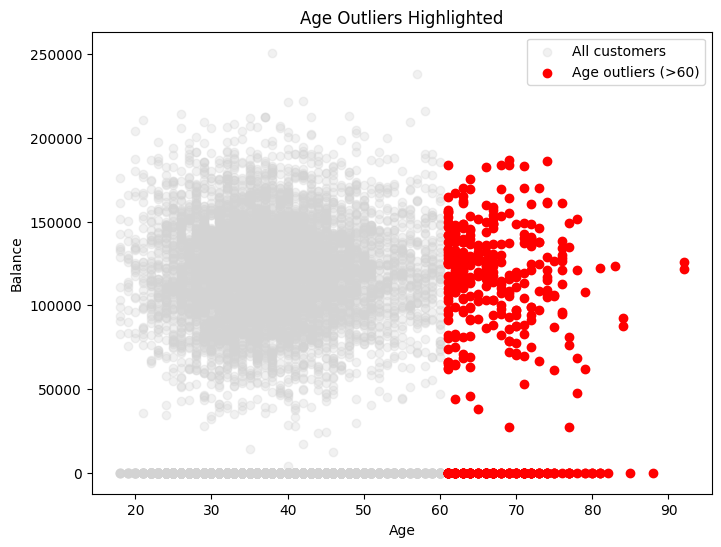

In [136]:
plt.figure(figsize=(8,6))
plt.scatter(df['Age'], df['Balance'], color='lightgray', alpha=0.3, label='All customers')

outliers = df[df['Age'] > 60]
plt.scatter(outliers['Age'], outliers['Balance'], color='red', label='Age outliers (>60)')

plt.xlabel('Age')
plt.ylabel('Balance')
plt.title('Age Outliers Highlighted')
plt.legend()
plt.show()

In [137]:
df[df['Age']>80]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
766,700,France,Female,82,2,0.00,2,0,1,182055.36,0
2458,513,Spain,Male,88,10,0.00,2,1,1,52952.24,0
3033,787,France,Female,85,10,0.00,2,1,1,116537.96,0
3387,537,Germany,Male,84,8,92242.34,1,1,1,186235.98,0
3531,408,France,Female,84,8,87873.39,1,0,0,188484.52,1
4931,682,Germany,Male,81,6,122029.15,1,1,1,50783.88,0
6443,753,France,Male,92,3,121513.31,1,0,1,195563.99,0
6759,705,France,Male,92,1,126076.24,2,1,1,34436.83,0
7526,850,France,Female,81,1,0.00,2,1,1,59568.24,0
7956,850,France,Male,81,5,0.00,2,1,1,44827.47,0


In [138]:
# Age outliers (>60, boxplot-flagged) checked against domain range - ages up to ~90s 
# are plausible, real customers, not data errors. Overlaps with the 'senior' AgeGroup 
# bucket from EDA (n=282, 15.2% churn). Retained - small sample size noted as a 
# limitation, but no basis to remove genuine customer data.

<Axes: ylabel='Balance'>

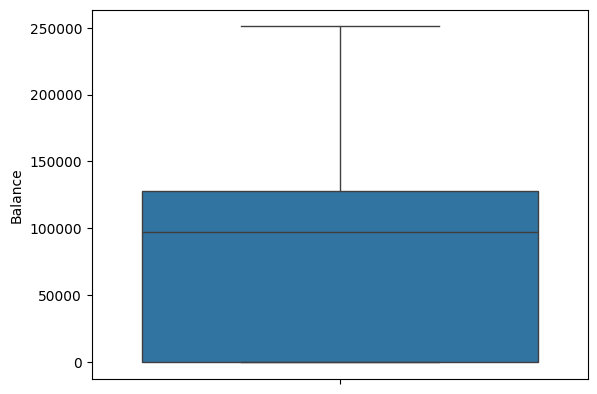

In [139]:
# balance 
sns.boxplot(df['Balance'])

<Axes: xlabel='Balance', ylabel='EstimatedSalary'>

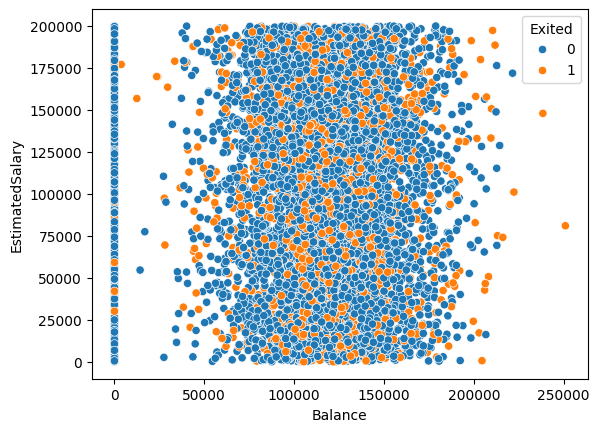

In [140]:
sns.scatterplot(x=df['Balance'],y=df['EstimatedSalary'],hue=df['Exited'])

<Axes: ylabel='EstimatedSalary'>

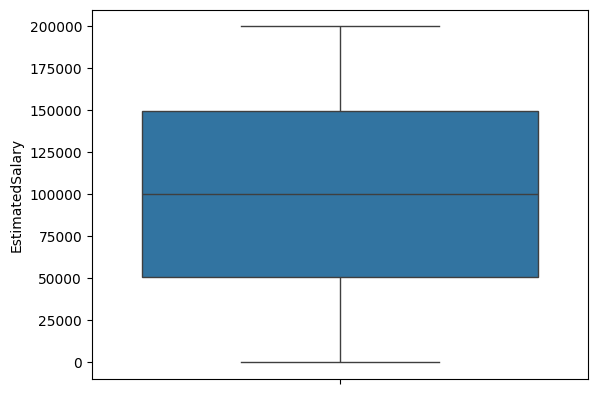

In [141]:
sns.boxplot(df['EstimatedSalary'])

# feature construction 



In [142]:
# there are some column which we have to construct in order to make it more understandable and pattern finder with model performence
#zero_balance_account,
# age group 
#credit_score_class
#tenure class

# zero_balance_account
df['zero_bal_acc']=(df['Balance']==0).astype(int)

# age_group
df['age_group']=pd.cut(df['Age'], bins=[17,39,64, 100], 
                          labels=['young', 'adult',"senior"]).astype('object')

# credit score class
df['credit_score_class']=pd.cut(df['CreditScore'],bins=[300,549,649,749,900],
                                  labels=['Poor','fair','good','excellent']).astype('object')

# tenure class
df['tenure_class']=pd.cut(df['Tenure'],bins=[-1,2,5,10],
                            labels=['short_term','mid_term','long_term']).astype('object')

In [143]:
df['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non-null  int64  
 8   IsActiveMember      10000 non-null  int64  
 9   EstimatedSalary     10000 non-null  float64
 10  Exited              10000 non-null  int64  
 11  zero_bal_acc        10000 non-null  int64  
 12  age_group           10000 non-null  object 
 13  credit_score_class  10000 non-null  object 
 14  tenure_class        10000 non-null  object 
dtypes: float64(2), int64(8), object(5)
memory usage: 1.1+ 

In [145]:
df[df['age_group'].isnull()]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,zero_bal_acc,age_group,credit_score_class,tenure_class


In [146]:
df.sample(4)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,zero_bal_acc,age_group,credit_score_class,tenure_class
7979,555,France,Female,26,7,0.00,2,1,0,93122.41,0,1,young,fair,long_term
7418,677,France,Male,36,4,0.00,2,1,0,7824.31,0,1,young,good,mid_term
5892,588,Germany,Male,35,3,104356.38,1,1,0,94498.82,0,0,young,fair,mid_term
2470,689,Spain,Female,31,3,139799.63,1,0,1,120663.57,0,0,young,good,mid_term


# encording the categorial values 

In [147]:
# Categorical Values
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
label_encoder = LabelEncoder()
ohe=OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore')


In [148]:
cat_values=df.select_dtypes(include='object').columns
cat_values

Index(['Geography', 'Gender', 'age_group', 'credit_score_class',
       'tenure_class'],
      dtype='object')

In [149]:
# age group
age_group_mapping = OrdinalEncoder(categories=[['young', 'adult', 'senior']])
df['age_group'] = age_group_mapping.fit_transform(df[['age_group']]).astype('int64')

# credit score class
credit_score_class_mapping = OrdinalEncoder(categories=[['Poor', 'fair', 'good', 'excellent']])
df['credit_score_class'] = credit_score_class_mapping.fit_transform(df[['credit_score_class']]).astype('int64')

# tenure class
tenure_class_mapping = OrdinalEncoder(categories=[['short_term', 'mid_term', 'long_term']])
df['tenure_class'] = tenure_class_mapping.fit_transform(df[['tenure_class']]).astype('int64')

In [150]:
# geography onehotencording
new_geo=ohe.fit_transform(df['Geography'].values.reshape(-1, 1)).astype('int64')   #gives output in array formate 
# to conver the array into dataframe we can use below code
geo_df=pd.DataFrame(new_geo,columns=ohe.get_feature_names_out(['Geography']))
# now we can concat the new dataframe with our main dataframe
df=pd.concat([df, geo_df], axis=1)

In [151]:
# label encording on the gender columns
df['Gender']=label_encoder.fit_transform(df['Gender']).astype('int64')

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  object 
 2   Gender              10000 non-null  int64  
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non-null  int64  
 8   IsActiveMember      10000 non-null  int64  
 9   EstimatedSalary     10000 non-null  float64
 10  Exited              10000 non-null  int64  
 11  zero_bal_acc        10000 non-null  int64  
 12  age_group           10000 non-null  int64  
 13  credit_score_class  10000 non-null  int64  
 14  tenure_class        10000 non-null  int64  
 15  Geography_Germany   10000 non-null  int64  
 16  Geogr

droping the columns which have been convert/transfred into new columns 

In [153]:
df.drop(columns=['Geography'],inplace=True)

In [154]:
df.sample(5)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,zero_bal_acc,age_group,credit_score_class,tenure_class,Geography_Germany,Geography_Spain
8185,722,0,40,6,89175.06,2,0,1,152883.95,0,0,1,2,2,1,0
5892,588,1,35,3,104356.38,1,1,0,94498.82,0,0,0,1,1,1,0
2592,505,1,40,6,47869.69,2,1,1,155061.97,0,0,1,0,2,1,0
5293,604,0,41,10,0.00,2,1,1,166224.39,0,1,1,1,2,0,1
3984,834,1,38,8,0.00,2,1,1,66485.26,0,1,0,3,2,0,1


# scaling the values 

In [155]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import robust_scale


In [156]:
df.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'zero_bal_acc', 'age_group', 'credit_score_class', 'tenure_class',
       'Geography_Germany', 'Geography_Spain'],
      dtype='object')

In [157]:
X=df.drop(columns=['Exited'])
y=df['Exited']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [158]:
# printing the split data shape
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (8000, 15)
x_test shape: (2000, 15)
y_train shape: (8000,)
y_test shape: (2000,)


we are dividing the data to 2 sectin one with standard scale and other with robust scale cause robust can handle outliers with good format

In [159]:
stand_scale=['Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
ROBUST_SCALE=['CreditScore', 'Age']

In [160]:
# standard scaling
scaler = StandardScaler()
x_train[stand_scale] = scaler.fit_transform(x_train[stand_scale])
x_test[stand_scale] = scaler.transform(x_test[stand_scale])
#robust scaling
x_train[ROBUST_SCALE] = robust_scale(x_train[ROBUST_SCALE])
x_test[ROBUST_SCALE] = robust_scale(x_test[ROBUST_SCALE])

In [161]:
# having a look at the scaled data
x_train.head(4)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,zero_bal_acc,age_group,credit_score_class,tenure_class,Geography_Germany,Geography_Spain
9254,0.246269,1,-0.416667,0.345680,-1.218471,0.808436,1,1,1.367670,1,0,2,2,0,0
1561,-0.156716,1,0.416667,-0.348369,0.696838,0.808436,1,1,1.661254,0,1,1,1,1,0
1670,-0.701493,1,-1.083333,-0.695393,0.618629,-0.916688,1,0,-0.252807,0,0,1,1,0,1
6087,-0.686567,0,-0.833333,1.386753,0.953212,-0.916688,1,0,0.915393,0,0,1,2,0,0


In [162]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 9254 to 7270
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         8000 non-null   float64
 1   Gender              8000 non-null   int64  
 2   Age                 8000 non-null   float64
 3   Tenure              8000 non-null   float64
 4   Balance             8000 non-null   float64
 5   NumOfProducts       8000 non-null   float64
 6   HasCrCard           8000 non-null   int64  
 7   IsActiveMember      8000 non-null   int64  
 8   EstimatedSalary     8000 non-null   float64
 9   zero_bal_acc        8000 non-null   int64  
 10  age_group           8000 non-null   int64  
 11  credit_score_class  8000 non-null   int64  
 12  tenure_class        8000 non-null   int64  
 13  Geography_Germany   8000 non-null   int64  
 14  Geography_Spain     8000 non-null   int64  
dtypes: float64(6), int64(9)
memory usage: 1000.0 KB


In [163]:
x_test.head(4)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,zero_bal_acc,age_group,credit_score_class,tenure_class,Geography_Germany,Geography_Spain
6252,-0.376164,1,-0.500000,-0.695393,0.329937,0.808436,0,0,-1.019605,0,0,1,1,1,0
4684,-0.175047,1,0.416667,-1.389442,-1.218471,0.808436,1,1,0.798883,1,1,1,0,0,0
1731,-0.338920,0,0.500000,-0.348369,-1.218471,0.808436,1,0,-0.727980,1,1,1,1,0,1
4742,-1.046555,1,1.750000,1.039728,0.689272,0.808436,1,1,1.221387,0,1,0,2,1,0


# feature selection

there are multiple ways to find the feature selection/importance 
1. correlation with label 
2. linear model 
3. random forest 
4. 

In [164]:
# correlation with output variable
corr_score=x_train.corrwith(y_train)
corr_df=corr_score.reset_index()
corr_df.columns=['Feature','Correlation']
corr_df = corr_df.sort_values('Correlation', ascending=False)
corr_df

,Feature,Correlation
2,Age,0.283173
10,age_group,0.272151
13,Geography_Germany,0.169537
4,Balance,0.118418
8,EstimatedSalary,0.010889
6,HasCrCard,-0.006471
12,tenure_class,-0.012714
3,Tenure,-0.013352
11,credit_score_class,-0.026500
0,CreditScore,-0.029307


In [165]:
# mutual information score
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(x_train, y_train)
mi_df = pd.DataFrame({'Feature': x_train.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False)

In [166]:
mi_df

,Feature,MI_Score
5,NumOfProducts,0.074717
2,Age,0.074634
10,age_group,0.054903
7,IsActiveMember,0.012584
13,Geography_Germany,0.011627
4,Balance,0.010729
9,zero_bal_acc,0.007028
3,Tenure,0.006533
14,Geography_Spain,0.005965
12,tenure_class,0.005886


# sequnetial backward elemintation


In [167]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [168]:
model = LogisticRegression(max_iter=1000, random_state=42)

In [169]:
print(f"model accuracy score train : {np.mean(cross_val_score(model,x_train,y_train,cv=5,scoring='accuracy'))}")
print(f"model accuracy score test : {np.mean(cross_val_score(model,x_test,y_test,cv=5,scoring='accuracy'))}")

model accuracy score train : 0.806625
model accuracy score test : 0.8109999999999999


ther is no overfitting in  the data which is a good sign  now lets start the featire selection meathod and check how much accuracy reduce as compre with the reduce in feature

In [170]:
std=SFS(model,k_features='best',forward=False,floating=False,verbose=0,cv=5,scoring='accuracy',n_jobs=-1)
std.fit(x_train,y_train)

,estimator,LogisticRegre...ndom_state=42)
,k_features,"(1, ...)"
,forward,False
,floating,False
,verbose,0
,scoring,'accuracy'
,cv,5
,n_jobs,-1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [171]:
std.k_score_

np.float64(0.8130000000000001)

In [172]:
std.k_feature_names_

('Age', 'IsActiveMember', 'zero_bal_acc', 'Geography_Germany')

In [173]:
metrix_df_sfs=pd.DataFrame.from_dict(std.get_metric_dict()).T

In [174]:
metrix_df_sfs=metrix_df_sfs.sort_values('avg_score',ascending=False)[['avg_score','feature_names']].head()


In [175]:
metrix_df_sfs

,avg_score,feature_names
4,0.813,"(Age, IsActiveMember, zero_bal_acc, Geography_..."
6,0.81275,"(Age, IsActiveMember, EstimatedSalary, zero_ba..."
5,0.812625,"(Age, IsActiveMember, EstimatedSalary, zero_ba..."
7,0.8125,"(Age, NumOfProducts, IsActiveMember, Estimated..."
8,0.81225,"(Age, NumOfProducts, IsActiveMember, Estimated..."


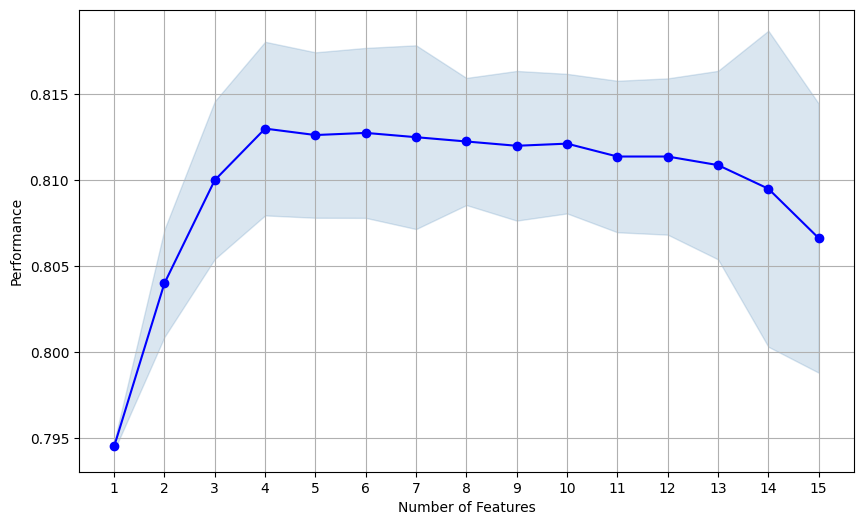

In [176]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
plot_sfs(std.get_metric_dict(), kind='std_dev', figsize=(10, 6))
plt.grid()

# exaustive feature selction

In [177]:
# Change this line
from mlxtend.feature_selection import ExhaustiveFeatureSelector as efs

# Your instantiation line will now work perfectly
sel = efs(model, max_features=6, scoring='accuracy', cv=5, n_jobs=-1)


In [178]:
sel.fit(x_train, y_train)

Features: 9948/9948

,estimator,LogisticRegre...ndom_state=42)
,min_features,1
,max_features,6
,print_progress,True
,scoring,'accuracy'
,cv,5
,n_jobs,-1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None
,feature_groups,"[[0], [1], ...]"


In [179]:
print(f"model best score : {sel.best_score_}")
print(f"model best features : {sel.best_feature_names_}")


model best score : 0.813375
model best features : ('Age', 'Balance', 'IsActiveMember', 'EstimatedSalary', 'zero_bal_acc', 'Geography_Germany')


In [180]:
metric_df_efs=pd.DataFrame.from_dict(sel.get_metric_dict()).T
metric_df_efs.sort_values(by='avg_score',ascending=False).head()

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
8705,"(2, 4, 7, 8, 9, 13)","[0.8125, 0.803125, 0.816875, 0.81375, 0.820625]",0.813375,"(Age, Balance, IsActiveMember, EstimatedSalary...",0.007512,0.005844,0.002922
1398,"(2, 7, 9, 13)","[0.81375, 0.80375, 0.816875, 0.8125, 0.818125]",0.813,"(Age, IsActiveMember, zero_bal_acc, Geography_...",0.006494,0.005053,0.002526
4103,"(2, 7, 9, 12, 13)","[0.81375, 0.803125, 0.81625, 0.813125, 0.818125]",0.812875,"(Age, IsActiveMember, zero_bal_acc, tenure_cla...",0.006675,0.005193,0.002597
8726,"(2, 4, 7, 9, 13, 14)","[0.813125, 0.8025, 0.81625, 0.81375, 0.81875]",0.812875,"(Age, Balance, IsActiveMember, zero_bal_acc, G...",0.007142,0.005557,0.002778
4034,"(2, 6, 7, 9, 13)","[0.813125, 0.80375, 0.816875, 0.8125, 0.818125]",0.812875,"(Age, HasCrCard, IsActiveMember, zero_bal_acc,...",0.006478,0.00504,0.00252


In [181]:
metrix_df_sfs=metrix_df_sfs.head()

In [182]:
metrix_df_sfs

,avg_score,feature_names
4,0.813,"(Age, IsActiveMember, zero_bal_acc, Geography_..."
6,0.81275,"(Age, IsActiveMember, EstimatedSalary, zero_ba..."
5,0.812625,"(Age, IsActiveMember, EstimatedSalary, zero_ba..."
7,0.8125,"(Age, NumOfProducts, IsActiveMember, Estimated..."
8,0.81225,"(Age, NumOfProducts, IsActiveMember, Estimated..."


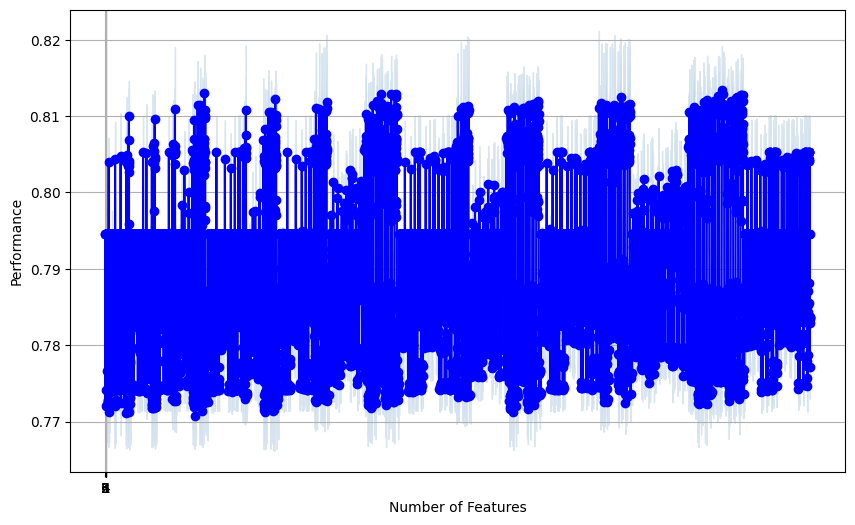

In [183]:
# plotting the grph
plot_sfs(sel.get_metric_dict(), kind='std_dev', figsize=(10, 6))
plt.grid()

# sequential forward selection


In [184]:
from mlxtend.feature_selection import SequentialFeatureSelector as sff

In [185]:
stdd=SFS(model,k_features='best',forward=True,floating=False,verbose=0,cv=5,scoring='accuracy',n_jobs=-1)
stdd.fit(x_train,y_train)

,estimator,LogisticRegre...ndom_state=42)
,k_features,"(1, ...)"
,forward,True
,floating,False
,verbose,0
,scoring,'accuracy'
,cv,5
,n_jobs,-1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [186]:
metric_df_sffs=pd.DataFrame.from_dict(stdd.get_metric_dict()).T
metric_df_sffs=metric_df_sffs.sort_values(by='avg_score',ascending=False)[['avg_score','feature_names']]

In [187]:
metric_df_sffs=metric_df_sffs.head()

In [188]:
# best feature name
stdd.k_feature_names_

('CreditScore',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'IsActiveMember',
 'Geography_Germany')

In [189]:
# best score
stdd.k_score_

np.float64(0.811375)

# embeded feature selection

In [190]:
from sklearn.linear_model import Lasso
model_lass=Lasso(alpha=0.0011)
model_lass.fit(x_train,y_train)

,alpha,0.0011
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [191]:
model_lass.coef_

array([-0.00768003, -0.07079493,  0.09754308, -0.00425446,  0.01950028,
       -0.00831946, -0.        , -0.13626511,  0.00073791, -0.        ,
        0.06351968, -0.00251456, -0.        ,  0.11618325,  0.00116601])

In [192]:
lasso_df=pd.DataFrame({'Feature':X.columns,'lasso_corr':model_lass.coef_}).sort_values('lasso_corr')

In [193]:
lasso_df

,Feature,lasso_corr
7,IsActiveMember,-0.136265
1,Gender,-0.070795
5,NumOfProducts,-0.008319
0,CreditScore,-0.007680
3,Tenure,-0.004254
11,credit_score_class,-0.002515
9,zero_bal_acc,-0.000000
6,HasCrCard,-0.000000
12,tenure_class,-0.000000
8,EstimatedSalary,0.000738


In [194]:
selected_features = X.columns[model_lass.coef_>0]
print("Selected Features:", selected_features.tolist())

Selected Features: ['Age', 'Balance', 'EstimatedSalary', 'age_group', 'Geography_Germany', 'Geography_Spain']


<Axes: >

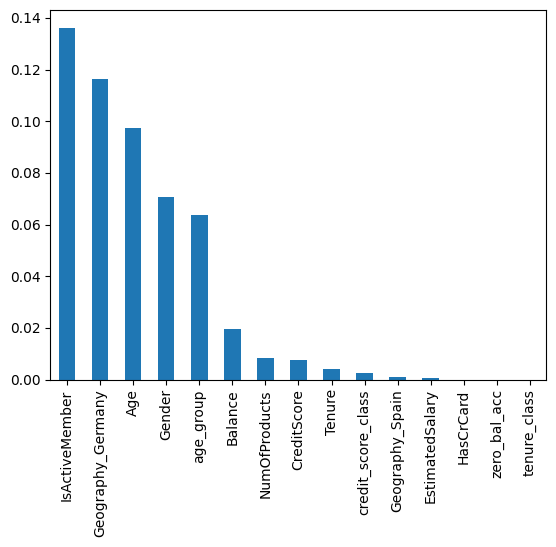

In [195]:
x = pd.Series(np.abs(model_lass.coef_),index=x_train.columns)

x.sort_values(ascending=False).plot(kind='bar')

In [196]:
from sklearn.feature_selection import SelectFromModel as sfm

In [197]:
modelsfm=sfm(estimator=model_lass,threshold='mean',max_features=13,prefit=True)

In [198]:
modelsfm.fit(x_train,y_train)

,estimator,Lasso(alpha=0.0011)
,threshold,'mean'
,prefit,True
,norm_order,1
,max_features,13
,importance_getter,'auto'
,alpha,0.0011
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000


In [199]:
sfm_df=modelsfm.feature_names_in_[modelsfm.get_support(indices=True)]

# feature importancce

In [200]:
from pandas.core.common import random_state
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

#dt.fit(X_train,y_train)
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [201]:
featurerf=rf.feature_importances_

In [202]:
rf.feature_names_in_

array(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'zero_bal_acc', 'age_group', 'credit_score_class', 'tenure_class',
       'Geography_Germany', 'Geography_Spain'], dtype=object)

In [203]:
rf_mat = pd.DataFrame({
    'Feature': rf.feature_names_in_,
    'rf_imp': rf.feature_importances_
})
rf_mat

,Feature,rf_imp
0,CreditScore,0.124848
1,Gender,0.021659
2,Age,0.183648
3,Tenure,0.070553
4,Balance,0.116814
5,NumOfProducts,0.128814
6,HasCrCard,0.019448
7,IsActiveMember,0.042032
8,EstimatedSalary,0.130856
9,zero_bal_acc,0.011130


<Axes: >

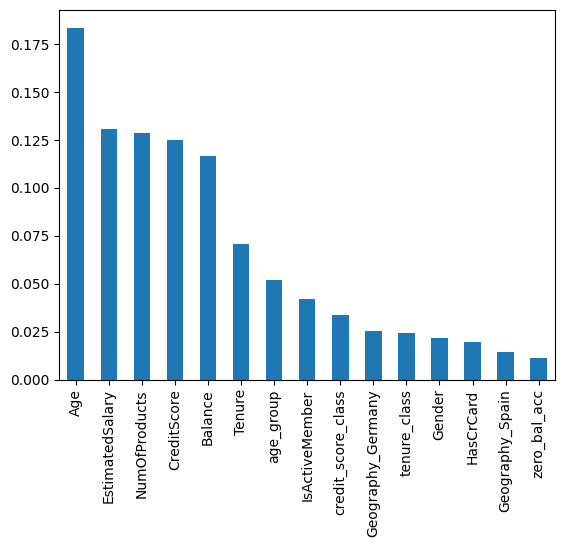

In [204]:
x = pd.Series(np.abs(rf.feature_importances_),index=x_train.columns)

x.sort_values(ascending=False).plot(kind='bar')

#RFC


In [205]:
from sklearn.feature_selection import  RFE
model_rff=RandomForestClassifier(max_depth=8,n_jobs=-1)
rfe = RFE(estimator=model_rff, n_features_to_select=1)

# Fit RFE
rfe.fit(x_train,y_train)

,estimator,"RandomForestC...=8, n_jobs=-1)"
,n_features_to_select,1
,step,1
,verbose,0
,importance_getter,'auto'
,n_estimators,100
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [206]:
# ranking 
ranking=rfe.ranking_

In [207]:
ranking

array([ 7, 10,  1,  9,  3,  2, 15,  4,  6, 11,  5, 12, 13,  8, 14])

In [208]:
data = []

for i, feature in enumerate(X.columns):
    data.append([feature, ranking[i]])
rfe_df = pd.DataFrame(data, columns=['Feature', 'rfe_imp'])
rfe_df

,Feature,rfe_imp
0,CreditScore,7
1,Gender,10
2,Age,1
3,Tenure,9
4,Balance,3
5,NumOfProducts,2
6,HasCrCard,15
7,IsActiveMember,4
8,EstimatedSalary,6
9,zero_bal_acc,11


here the 1 means the best model and rest gos down the rank then 

# feature shortlisting 

backward

In [209]:
metrix_df_sfs

,avg_score,feature_names
4,0.813,"(Age, IsActiveMember, zero_bal_acc, Geography_..."
6,0.81275,"(Age, IsActiveMember, EstimatedSalary, zero_ba..."
5,0.812625,"(Age, IsActiveMember, EstimatedSalary, zero_ba..."
7,0.8125,"(Age, NumOfProducts, IsActiveMember, Estimated..."
8,0.81225,"(Age, NumOfProducts, IsActiveMember, Estimated..."


In [210]:
std.k_feature_names_

('Age', 'IsActiveMember', 'zero_bal_acc', 'Geography_Germany')

forward

In [211]:
metric_df_sffs

,avg_score,feature_names
8,0.811375,"(CreditScore, Gender, Age, Tenure, Balance, Nu..."
9,0.811375,"(CreditScore, Gender, Age, Tenure, Balance, Nu..."
10,0.811125,"(CreditScore, Gender, Age, Tenure, Balance, Nu..."
11,0.81075,"(CreditScore, Gender, Age, Tenure, Balance, Nu..."
12,0.8105,"(CreditScore, Gender, Age, Tenure, Balance, Nu..."


In [212]:
stdd.k_feature_names_

('CreditScore',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'IsActiveMember',
 'Geography_Germany')

In [213]:
sfm_df


array(['Gender', 'Age', 'IsActiveMember', 'age_group',
       'Geography_Germany'], dtype=object)

In [214]:
merged_df = merged_df = (
    mi_df
    .merge(corr_df, on='Feature').
    merge(lasso_df,on='Feature').
    merge(rf_mat,on='Feature').
    merge(rfe_df,on='Feature')
).sort_values('rfe_imp')

In [215]:
merged_df.T

,1,0,5,3,2,12,11,4,7,13,6,10,9,8,14
Feature,Age,NumOfProducts,Balance,IsActiveMember,age_group,EstimatedSalary,CreditScore,Geography_Germany,Tenure,Gender,zero_bal_acc,credit_score_class,tenure_class,Geography_Spain,HasCrCard
MI_Score,0.074634,0.074717,0.010729,0.012584,0.054903,0.003589,0.003654,0.011627,0.006533,0.00291,0.007028,0.004597,0.005886,0.005965,0.001436
Correlation,0.283173,-0.051009,0.118418,-0.15656,0.272151,0.010889,-0.029307,0.169537,-0.013352,-0.106478,-0.124452,-0.0265,-0.012714,-0.047172,-0.006471
lasso_corr,0.097543,-0.008319,0.0195,-0.136265,0.06352,0.000738,-0.00768,0.116183,-0.004254,-0.070795,-0.0,-0.002515,-0.0,0.001166,-0.0
rf_imp,0.183648,0.128814,0.116814,0.042032,0.051959,0.130856,0.124848,0.02543,0.070553,0.021659,0.01113,0.033868,0.024415,0.014527,0.019448
rfe_imp,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15


In [216]:
import openpyxl
print(openpyxl.__version__)

3.1.5


converting the csv file into exel sheet for analyses which top 8 feature should we be working on 

In [217]:
merged_df.to_excel(
    r"D:\skill improvement\churn data\data\feature selection1.xlsx",
    index=False
)

# top feature with comman in every method
Age
Geography_Germany
Balance
age_group
IsActiveMember
EstimatedSalary
NumOfProducts
CreditScore
Tenure
Gender


lets check wther they have any impact on the prediction or not 


In [218]:
# lets check wther age and age group have anything in comman
x_train['Age'].corr(x_train['age_group'],method='pearson')

np.float64(0.8474049868669774)

In [219]:
# Quick correlation check across all your numeric/encoded features
corr_matrix = x_train.corr()

# Find pairs with high correlation (excluding the diagonal, which is always 1.0)
high_corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[(high_corr_pairs < 1.0) & (high_corr_pairs > 0.7)]
print(high_corr_pairs)

CreditScore         credit_score_class    0.947032
credit_score_class  CreditScore           0.947032
tenure_class        Tenure                0.928380
Tenure              tenure_class          0.928380
Balance             zero_bal_acc          0.923295
zero_bal_acc        Balance               0.923295
age_group           Age                   0.847405
Age                 age_group             0.847405
dtype: float64


we are froping the age group from the selected feature as it have high correlation metrixwith the age feature around 84 which is flag letssee it dropingt he age group have any change on the prediction

In [220]:
# trainng a model and prediting for all the features and checking there score 
x_train_selected=x_train[['Age','Geography_Germany','Balance','IsActiveMember','EstimatedSalary','NumOfProducts','CreditScore','Tenure','Gender']]
x_test_selected=x_test[['Age','Geography_Germany','Balance','IsActiveMember','EstimatedSalary','NumOfProducts','CreditScore','Tenure','Gender']]

In [221]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

smote = SMOTE(random_state=42)

# 1. SMOTE the full-feature training set
x_train_full_smote, y_train_full_smote = smote.fit_resample(x_train, y_train)

# 2. SMOTE the selected (top-10) training set
x_train_sel_smote, y_train_sel_smote = smote.fit_resample(x_train_selected, y_train)

# 3. Train model on FULL features (SMOTE'd)
rf_full = RandomForestClassifier(random_state=42)
rf_full.fit(x_train_full_smote, y_train_full_smote)

# 4. Train model on SELECTED features (SMOTE'd)
rf_selected = RandomForestClassifier(random_state=42)
rf_selected.fit(x_train_sel_smote, y_train_sel_smote)

# 5. Predict on the REAL, untouched test set (never SMOTE'd) — same test set for both
pred_full = rf_full.predict(x_test)
pred_selected = rf_selected.predict(x_test_selected)

prob_full = rf_full.predict_proba(x_test)[:, 1]
prob_selected = rf_selected.predict_proba(x_test_selected)[:, 1]

# 6. Compare
print("=== Full Features (SMOTE) ===")
print(f"Accuracy: {accuracy_score(y_test, pred_full):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, prob_full):.4f}")
print(classification_report(y_test, pred_full))

print("\n=== Top 10 Selected Features (SMOTE) ===")
print(f"Accuracy: {accuracy_score(y_test, pred_selected):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, prob_selected):.4f}")
print(classification_report(y_test, pred_selected))

=== Full Features (SMOTE) ===
Accuracy: 0.8515
ROC-AUC: 0.8537
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1607
           1       0.63      0.59      0.61       393

    accuracy                           0.85      2000
   macro avg       0.77      0.75      0.76      2000
weighted avg       0.85      0.85      0.85      2000


=== Top 10 Selected Features (SMOTE) ===
Accuracy: 0.8415
ROC-AUC: 0.8480
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1607
           1       0.60      0.59      0.60       393

    accuracy                           0.84      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.84      0.84      0.84      2000



In [222]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Build a pipeline: SMOTE + model, bundled together
pipeline_full = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

pipeline_selected = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

# Now cross_val_score applies SMOTE fresh within each fold's TRAINING portion only
scores_full = cross_val_score(pipeline_full, X, y, cv=5, scoring='roc_auc')
scores_selected = cross_val_score(pipeline_selected, X[['Age','Geography_Germany','Balance','IsActiveMember','EstimatedSalary','NumOfProducts','CreditScore','Tenure','Gender']], y, cv=5, scoring='roc_auc')

print(f"Full features CV ROC-AUC: {scores_full.mean():.4f} (+/- {scores_full.std():.4f})")
print(f"Selected features CV ROC-AUC: {scores_selected.mean():.4f} (+/- {scores_selected.std():.4f})")

Full features CV ROC-AUC: 0.8285 (+/- 0.0065)
Selected features CV ROC-AUC: 0.8326 (+/- 0.0084)


Feature Selection Validation
An initial single train/test split comparison suggested the full feature set slightly outperformed the top-10 selected features. However, 5-fold cross-validation — a more reliable estimate — showed the opposite direction (selected: 0.8326 ± 0.0084 vs. full: 0.8285 ± 0.0065), with substantially overlapping confidence ranges. This indicates the apparent difference in both tests was within normal noise, not a real effect: the top-10 selected features perform statistically equivalently to the full feature set. Given this, the reduced feature set is the better practical choice — it achieves comparable predictive performance with a simpler, more interpretable model.

In [223]:
X.shape

(10000, 15)

In [224]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,zero_bal_acc,age_group,credit_score_class,tenure_class,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,1,1,0,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1,1,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,1,0,2,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,2,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1,3,0,0,1


In [230]:
x_train.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,zero_bal_acc,age_group,credit_score_class,tenure_class,Geography_Germany,Geography_Spain
9254,0.246269,1,-0.416667,0.345680,-1.218471,0.808436,1,1,1.367670,1,0,2,2,0,0
1561,-0.156716,1,0.416667,-0.348369,0.696838,0.808436,1,1,1.661254,0,1,1,1,1,0
1670,-0.701493,1,-1.083333,-0.695393,0.618629,-0.916688,1,0,-0.252807,0,0,1,1,0,1
6087,-0.686567,0,-0.833333,1.386753,0.953212,-0.916688,1,0,0.915393,0,0,1,2,0,0
6669,-1.014925,1,1.583333,1.386753,1.057449,-0.916688,0,0,-1.059600,0,1,0,2,0,0


In [226]:
final_df=X[['Age','Geography_Germany','Balance','IsActiveMember','EstimatedSalary','NumOfProducts','CreditScore','Tenure','Gender']]
final_df['Exited']=y

C:\Users\karan\AppData\Local\Temp\ipykernel_18492\2367068725.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['Exited']=y


In [227]:
final_df.head()

,Age,Geography_Germany,Balance,IsActiveMember,EstimatedSalary,NumOfProducts,CreditScore,Tenure,Gender,Exited
0,42,0,0.00,1,101348.88,1,619,2,0,1
1,41,0,83807.86,1,112542.58,1,608,1,0,0
2,42,0,159660.80,0,113931.57,3,502,8,0,1
3,39,0,0.00,0,93826.63,2,699,1,0,0
4,43,0,125510.82,1,79084.10,1,850,2,0,0


In [229]:
final_df.to_csv(r"D:\\skill improvement\\churn data\\data\\processed data\\final_df",index=False)
